In [1]:
import torch
from torch import nn


import pandas as pd
# import torchvision
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

# Import matplotlib for visualization
import matplotlib.pyplot as plt

import os

print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

PyTorch version: 2.10.0+cpu
torchvision version: 0.25.0+cpu


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [3]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [4]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".yaml") or file.endswith(".yml"):
            print(os.path.join(root, file))

/kaggle/input/datasets/banuprasadb/wildlife-dataset/data.yaml


In [5]:
import os
import shutil
import yaml
from tqdm import tqdm

# --------------------------
# Load class names from data.yaml
# --------------------------
yaml_path = "/kaggle/input/datasets/banuprasadb/wildlife-dataset/data.yaml"

with open(yaml_path, "r") as f:
    cfg = yaml.safe_load(f)

# Handle both dictionary and list formats
if isinstance(cfg["names"], dict):
    class_names = list(cfg["names"].values())
else:
    class_names = cfg["names"]

print("Classes:", class_names)

# Dataset root
root = "/kaggle/input/datasets/banuprasadb/wildlife-dataset"

datasets = ["train", "valid", "test"]

# Output folder
output_root = "/kaggle/working/wildlife_dataset_classification"
os.makedirs(output_root, exist_ok=True)

# --------------------------
# Convert YOLO → ImageFolder Format
# --------------------------
for split in datasets:
    print(f"\nProcessing: {split}")

    img_dir = os.path.join(root, split, "images")
    label_dir = os.path.join(root, split, "labels")

    if not os.path.exists(img_dir):
        print(f"Image folder not found: {img_dir}")
        continue

    if not os.path.exists(label_dir):
        print(f"Label folder not found: {label_dir}")
        continue

    # Create output split directory
    out_split = os.path.join(output_root, split)
    os.makedirs(out_split, exist_ok=True)

    # Create class folders
    for cname in class_names:
        os.makedirs(os.path.join(out_split, cname), exist_ok=True)

    # Process labels
    for label_file in tqdm(os.listdir(label_dir), desc=split):

        if not label_file.endswith(".txt"):
            continue

        label_path = os.path.join(label_dir, label_file)

        with open(label_path, "r") as f:
            first_line = f.readline().strip()

        if first_line == "":
            continue

        parts = first_line.split()

        if len(parts) == 0:
            continue

        cls_id = int(parts[0])

        if cls_id >= len(class_names):
            print(f"Invalid class id {cls_id} in {label_file}")
            continue

        cls_name = class_names[cls_id]

        # Find corresponding image
        base_name = os.path.splitext(label_file)[0]

        img_path = None
        for ext in [".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"]:
            candidate = os.path.join(img_dir, base_name + ext)
            if os.path.exists(candidate):
                img_path = candidate
                img_name = base_name + ext
                break

        if img_path is None:
            print(f"Image not found for {label_file}")
            continue

        # Copy image
        shutil.copy2(
            img_path,
            os.path.join(out_split, cls_name, img_name)
        )

print("\n Conversion completed!")
print(f"Dataset saved at: {output_root}")

Classes: ['Zebra', 'Lion', 'Leopard', 'Cheetah', 'Tiger', 'Bear', 'Butterfly', 'Canary', 'Crocodile', 'Bull', 'Camel', 'Centipede', 'Caterpillar', 'Duck', 'Squirrel', 'Spider', 'Ladybug', 'Elephant', 'Horse', 'Fox', 'Tortoise', 'Frog', 'Kangaroo', 'Deer', 'Eagle', 'Monkey', 'Snake', 'Owl', 'Swan', 'Goat', 'Rabbit', 'Giraffe', 'Goose', 'PolarBear', 'Raven', 'Hippopotamus', 'BrownBear', 'Rhinoceros', 'Woodpecker', 'Sheep', 'Magpie', 'Ostrich', 'Jaguar', 'Hedgehog', 'Turkey', 'Raccoon', 'Worm', 'Harbor', 'Panda', 'RedPanda', 'Otter', 'Lynx', 'Scorpion', 'Koala']

Processing: train


train: 100%|██████████| 13605/13605 [05:03<00:00, 44.77it/s]



Processing: valid


valid: 100%|██████████| 1748/1748 [00:43<00:00, 39.96it/s]



Processing: test


test: 100%|██████████| 1717/1717 [00:40<00:00, 42.33it/s]


 Conversion completed!
Dataset saved at: /kaggle/working/wildlife_dataset_classification


In [6]:
train_dir = "/kaggle/working/wildlife_dataset_classification/train"
test_dir = "/kaggle/working/wildlife_dataset_classification/test"
val_dir = "/kaggle/working/wildlife_dataset_classification/valid"

In [7]:
print(os.listdir(train_dir))

['Caterpillar', 'Rhinoceros', 'Tiger', 'Sheep', 'Leopard', 'Giraffe', 'Lion', 'Squirrel', 'Rabbit', 'Cheetah', 'Deer', 'Canary', 'Elephant', 'Kangaroo', 'Magpie', 'Harbor', 'Raccoon', 'Turkey', 'Tortoise', 'Fox', 'Bear', 'Snake', 'Owl', 'Butterfly', 'Panda', 'RedPanda', 'Monkey', 'Hippopotamus', 'Crocodile', 'Eagle', 'Duck', 'Zebra', 'Ladybug', 'Otter', 'Goat', 'Camel', 'Hedgehog', 'Woodpecker', 'Bull', 'Lynx', 'Koala', 'Frog', 'Worm', 'Jaguar', 'Raven', 'BrownBear', 'Scorpion', 'Centipede', 'Spider', 'Ostrich', 'Horse', 'Swan', 'Goose', 'PolarBear']


Random image path: /kaggle/working/wildlife_dataset_classification/train/Frog/d38ff54b48634ece.jpg
Image class: Frog
Image height: 1024
Image width: 768
Image mode: RGB


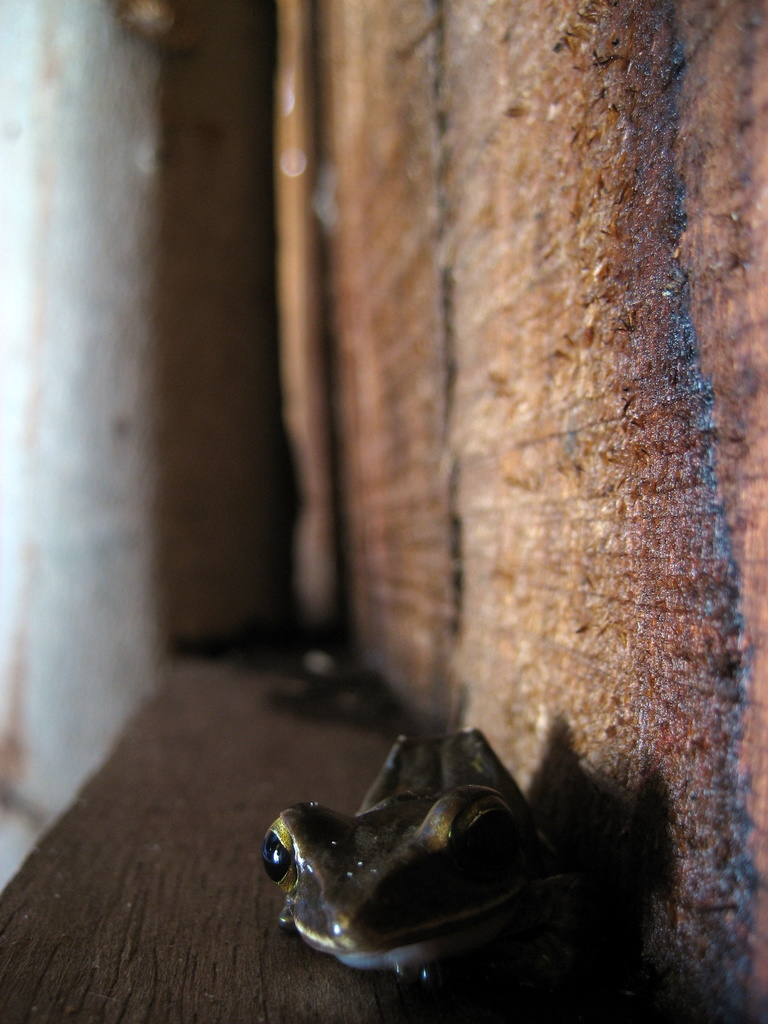

In [8]:
import os
import random
from pathlib import Path
from PIL import Image

random.seed(42)

# Convert your original data_dir string to a path_object
base_dir = Path(train_dir)

# 1. Get all image paths 
image_path_list = list(base_dir.glob("*/*.jpg"))

# 2. Pick a random image
random_image_path = random.choice(image_path_list)

# 3. Get image class from directory name
image_class = os.path.basename(os.path.dirname(random_image_path))

# 4. Open image
img = Image.open(random_image_path)

# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}") 
print(f"Image width: {img.width}")
print(f"Image mode: {img.mode}")

# Display the image
img

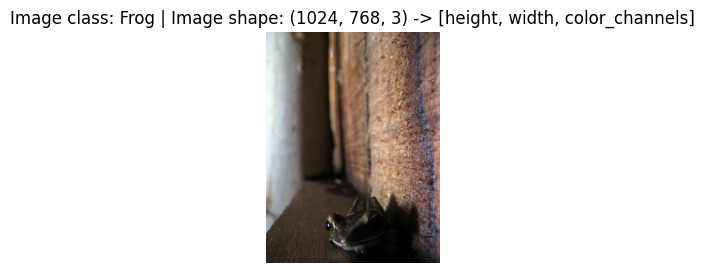

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize=(4, 3))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False);
